# Taller: Filtros Personalizados y Convolución 2D

**Objetivo:** Diseñar e implementar filtros personalizados en imágenes para modificar bordes, difuminar o realzar detalles. Se profundiza en el concepto de convolución y su impacto visual.

**Herramientas:** `opencv-python`, `numpy`, `matplotlib`

## Celda 1: Imports y utilidades

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time

def show(img, title="", cmap="gray", figsize=(5, 5)):
    """Muestra una imagen con matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def normalize_uint8(x):
    """Normaliza un array float a rango [0, 255] uint8."""
    x = np.asarray(x, dtype=np.float32)
    x = cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX)
    return x.astype(np.uint8)

print("Librerías importadas correctamente.")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

Librerías importadas correctamente.
OpenCV version: 4.13.0
NumPy version: 2.3.5


## Celda 2: Cargar imagen en escala de grises

Si no existe `imagen.jpg` en el directorio, se genera automáticamente una imagen sintética con figuras geométricas para que el notebook siempre funcione.

No se encontró 'imagen.jpg'.
Generando imagen sintética con figuras geométricas...
Imagen sintética generada exitosamente.
Dimensiones: (400, 400) | Tipo: uint8


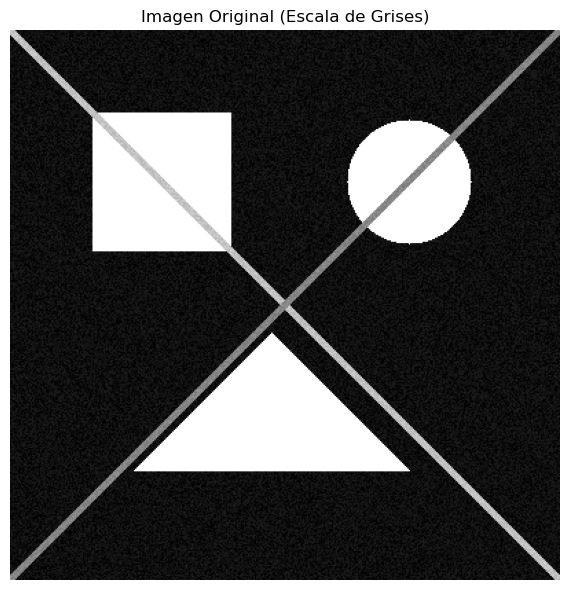

In [2]:
image_path = "imagen.jpg" 

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"No se encontró '{image_path}'.")
    print("Generando imagen sintética con figuras geométricas...")

    img = np.zeros((400, 400), dtype=np.uint8)

    # Rectángulo
    cv2.rectangle(img, (60, 60), (160, 160), 255, -1)
    # Círculo
    cv2.circle(img, (290, 110), 45, 255, -1)
    # Triángulo
    pts = np.array([[90, 320], [190, 220], [290, 320]], np.int32)
    cv2.fillPoly(img, [pts], 255)
    # Líneas diagonales
    cv2.line(img, (0, 0), (399, 399), 180, 4)
    cv2.line(img, (399, 0), (0, 399), 120, 3)
    # Ruido leve para bordes más interesantes
    noise = np.random.randint(0, 30, img.shape, dtype=np.uint8)
    img = cv2.add(img, noise)

    print("Imagen sintética generada exitosamente.")
else:
    print(f"Imagen '{image_path}' cargada correctamente.")

print(f"Dimensiones: {img.shape} | Tipo: {img.dtype}")
show(img, "Imagen Original (Escala de Grises)", figsize=(6, 6))

## Celda 3: Implementación manual de convolución 2D desde cero

Se implementa la operación de convolución 2D píxel a píxel usando NumPy, sin depender de funciones de alto nivel de OpenCV.

**Fórmula:** $(f * g)[i,j] = \sum_m \sum_n f[i-m, j-n] \cdot g[m,n]$

In [3]:
def conv2d_manual(image, kernel):
    """
    Aplica un kernel personalizado a cada píxel de la imagen mediante convolución 2D.

    Parámetros:
    -----------
    image  : np.ndarray  -> Imagen de entrada en escala de grises (2D)
    kernel : np.ndarray  -> Kernel/filtro a aplicar

    Retorna:
    --------
    out : np.ndarray (float32) -> Imagen filtrada
    """
    image  = image.astype(np.float32)
    kernel = kernel.astype(np.float32)

    h, w   = image.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    # Padding reflejo para evitar artefactos en los bordes
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="reflect")
    out = np.zeros((h, w), dtype=np.float32)

    # Recorrido píxel a píxel
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)  # Producto elemento a elemento

    return out

print("Función conv2d_manual definida.")
print("Nota: La implementación manual es más lenta que OpenCV, esto es esperado.")

Función conv2d_manual definida.
Nota: La implementación manual es más lenta que OpenCV, esto es esperado.


## Celda 4: Definición de kernels

Se definen los tres kernels requeridos por el taller:
1. **Sharpening** (enfoque/realce de detalles)
2. **Blur** (suavizado)
3. **Sobel X e Y** (para detección de bordes y esquinas)

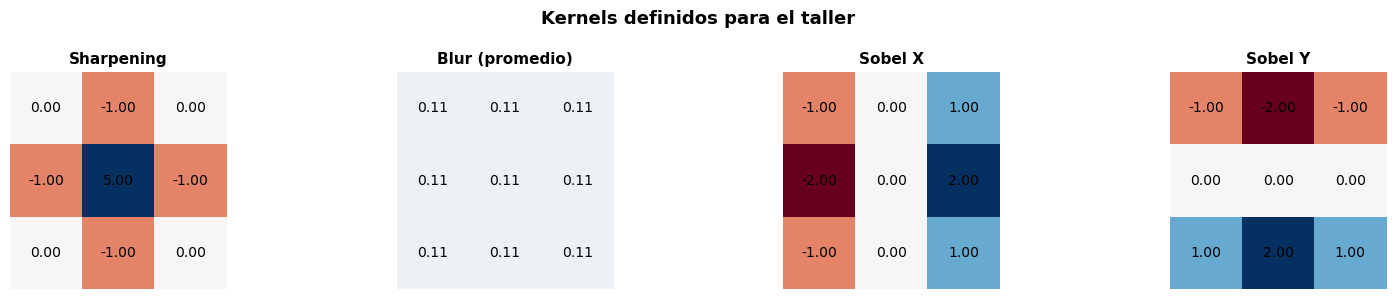

In [4]:
# ── Kernel 1: Sharpening (Laplaciano + identidad) ──────────────────────────────
# Aumenta el contraste local resaltando cambios de intensidad
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# ── Kernel 2: Blur (promedio) ──────────────────────────────────────────────────
# Suaviza la imagen promediando los píxeles vecinos
kernel_blur = np.ones((3, 3), dtype=np.float32) / 9.0

# ── Kernels 3a y 3b: Sobel X e Y (gradientes parciales) ──────────────────────
# Usados para detección de bordes y construcción de la respuesta de esquinas
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# ── Kernel de suavizado para la respuesta Harris ──────────────────────────────
smooth_3x3 = np.ones((3, 3), dtype=np.float32) / 9.0

# Visualización de los kernels
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
kernels = [kernel_sharpen, kernel_blur, sobel_x, sobel_y]
names   = ["Sharpening", "Blur (promedio)", "Sobel X", "Sobel Y"]

for ax, k, name in zip(axes, kernels, names):
    im = ax.imshow(k, cmap="RdBu", vmin=-2, vmax=2)
    ax.set_title(name, fontsize=11, fontweight='bold')
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            ax.text(j, i, f"{k[i,j]:.2f}", ha="center", va="center",
                    fontsize=10, color="black")
    ax.axis("off")

plt.suptitle("Kernels definidos para el taller", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Celda 5: Aplicar filtros con la convolución manual

> **Atención:** La convolución manual recorre cada píxel en Python puro. En imágenes grandes puede tardar varios segundos. Esto es intencional: permite comparar el tiempo con OpenCV en la Celda 10.

In [5]:
print("Aplicando convolución manual... (puede tardar unos segundos)")

t0 = time.time()

# Sharpening manual
sharp_manual = conv2d_manual(img, kernel_sharpen)

# Blur manual
blur_manual  = conv2d_manual(img, kernel_blur)

# Gradientes Sobel manuales
ix_manual = conv2d_manual(img, sobel_x)
iy_manual = conv2d_manual(img, sobel_y)

# Magnitud del gradiente (bordes)
edges_manual = np.sqrt(ix_manual**2 + iy_manual**2)

manual_total = time.time() - t0
print(f"Tiempo total (manual): {manual_total:.3f} s")

Aplicando convolución manual... (puede tardar unos segundos)
Tiempo total (manual): 18.954 s


## Celda 6: Aplicar filtros con OpenCV

Se usan `cv2.filter2D()` y `cv2.Sobel()` para obtener los mismos resultados de forma optimizada.

In [6]:
t0 = time.time()

# Sharpening OpenCV
sharp_cv = cv2.filter2D(img, cv2.CV_32F, kernel_sharpen,
                        borderType=cv2.BORDER_REFLECT101)

# Blur OpenCV
blur_cv  = cv2.filter2D(img, cv2.CV_32F, kernel_blur,
                        borderType=cv2.BORDER_REFLECT101)

# Gradientes Sobel OpenCV
ix_cv = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3,
                  borderType=cv2.BORDER_REFLECT101)
iy_cv = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3,
                  borderType=cv2.BORDER_REFLECT101)

# Magnitud del gradiente (bordes)
edges_cv = np.sqrt(ix_cv**2 + iy_cv**2)

opencv_total = time.time() - t0
print(f"Tiempo total (OpenCV): {opencv_total:.6f} s")
print(f"OpenCV es aprox. {manual_total/opencv_total:.0f}x más rápido que la implementación manual.")

Tiempo total (OpenCV): 0.012927 s
OpenCV es aprox. 1466x más rápido que la implementación manual.


## Celda 7: Detección de esquinas con Sobel + derivadas cruzadas (Harris)

Las **esquinas** se detectan usando la **respuesta de Harris**, que combina:
- $I_x^2$: gradiente horizontal al cuadrado
- $I_y^2$: gradiente vertical al cuadrado  
- $I_x I_y$: **derivada cruzada** (término que distingue esquinas de bordes)

$$R = \det(M) - k \cdot \text{tr}(M)^2 \quad \text{donde} \quad M = \begin{bmatrix} S_{xx} & S_{xy} \\ S_{xy} & S_{yy} \end{bmatrix}$$

Valores altos de $R$ → esquinas. Valores muy negativos → bordes.

In [7]:
k = 0.04  # Constante de sensibilidad de Harris (típicamente entre 0.04 y 0.06)

# ── Respuesta de Harris MANUAL ─────────────────────────────────────────────────
# Suavizado de los productos de gradientes
sxx_manual = conv2d_manual(ix_manual**2,          smooth_3x3)
syy_manual = conv2d_manual(iy_manual**2,          smooth_3x3)
sxy_manual = conv2d_manual(ix_manual * iy_manual, smooth_3x3)  # Derivada cruzada

# Medida de respuesta de esquina
corner_response_manual = (sxx_manual * syy_manual - sxy_manual**2) \
                       - k * (sxx_manual + syy_manual)**2

# ── Respuesta de Harris con OpenCV ────────────────────────────────────────────
sxx_cv = cv2.filter2D(ix_cv**2,        cv2.CV_32F, smooth_3x3,
                      borderType=cv2.BORDER_REFLECT101)
syy_cv = cv2.filter2D(iy_cv**2,        cv2.CV_32F, smooth_3x3,
                      borderType=cv2.BORDER_REFLECT101)
sxy_cv = cv2.filter2D(ix_cv * iy_cv,   cv2.CV_32F, smooth_3x3,
                      borderType=cv2.BORDER_REFLECT101)

corner_response_cv = (sxx_cv * syy_cv - sxy_cv**2) \
                   - k * (sxx_cv + syy_cv)**2

# ── Normalización a uint8 para visualización ──────────────────────────────────
sharp_manual_u8  = normalize_uint8(sharp_manual)
blur_manual_u8   = normalize_uint8(blur_manual)
edges_manual_u8  = normalize_uint8(edges_manual)
corner_manual_u8 = normalize_uint8(corner_response_manual)

sharp_cv_u8      = normalize_uint8(sharp_cv)
blur_cv_u8       = normalize_uint8(blur_cv)
edges_cv_u8      = normalize_uint8(edges_cv)
corner_cv_u8     = normalize_uint8(corner_response_cv)

print("Respuesta de esquinas calculada (Manual + OpenCV).")
print(f"k = {k} | Rango manual: [{corner_response_manual.min():.1f}, {corner_response_manual.max():.1f}]")

Respuesta de esquinas calculada (Manual + OpenCV).
k = 0.04 | Rango manual: [-17373835264.0, 85642059776.0]


## Celda 8: Comparación visual en paralelo

Se muestran todos los resultados lado a lado: **Manual** (izquierda) vs **OpenCV** (derecha).

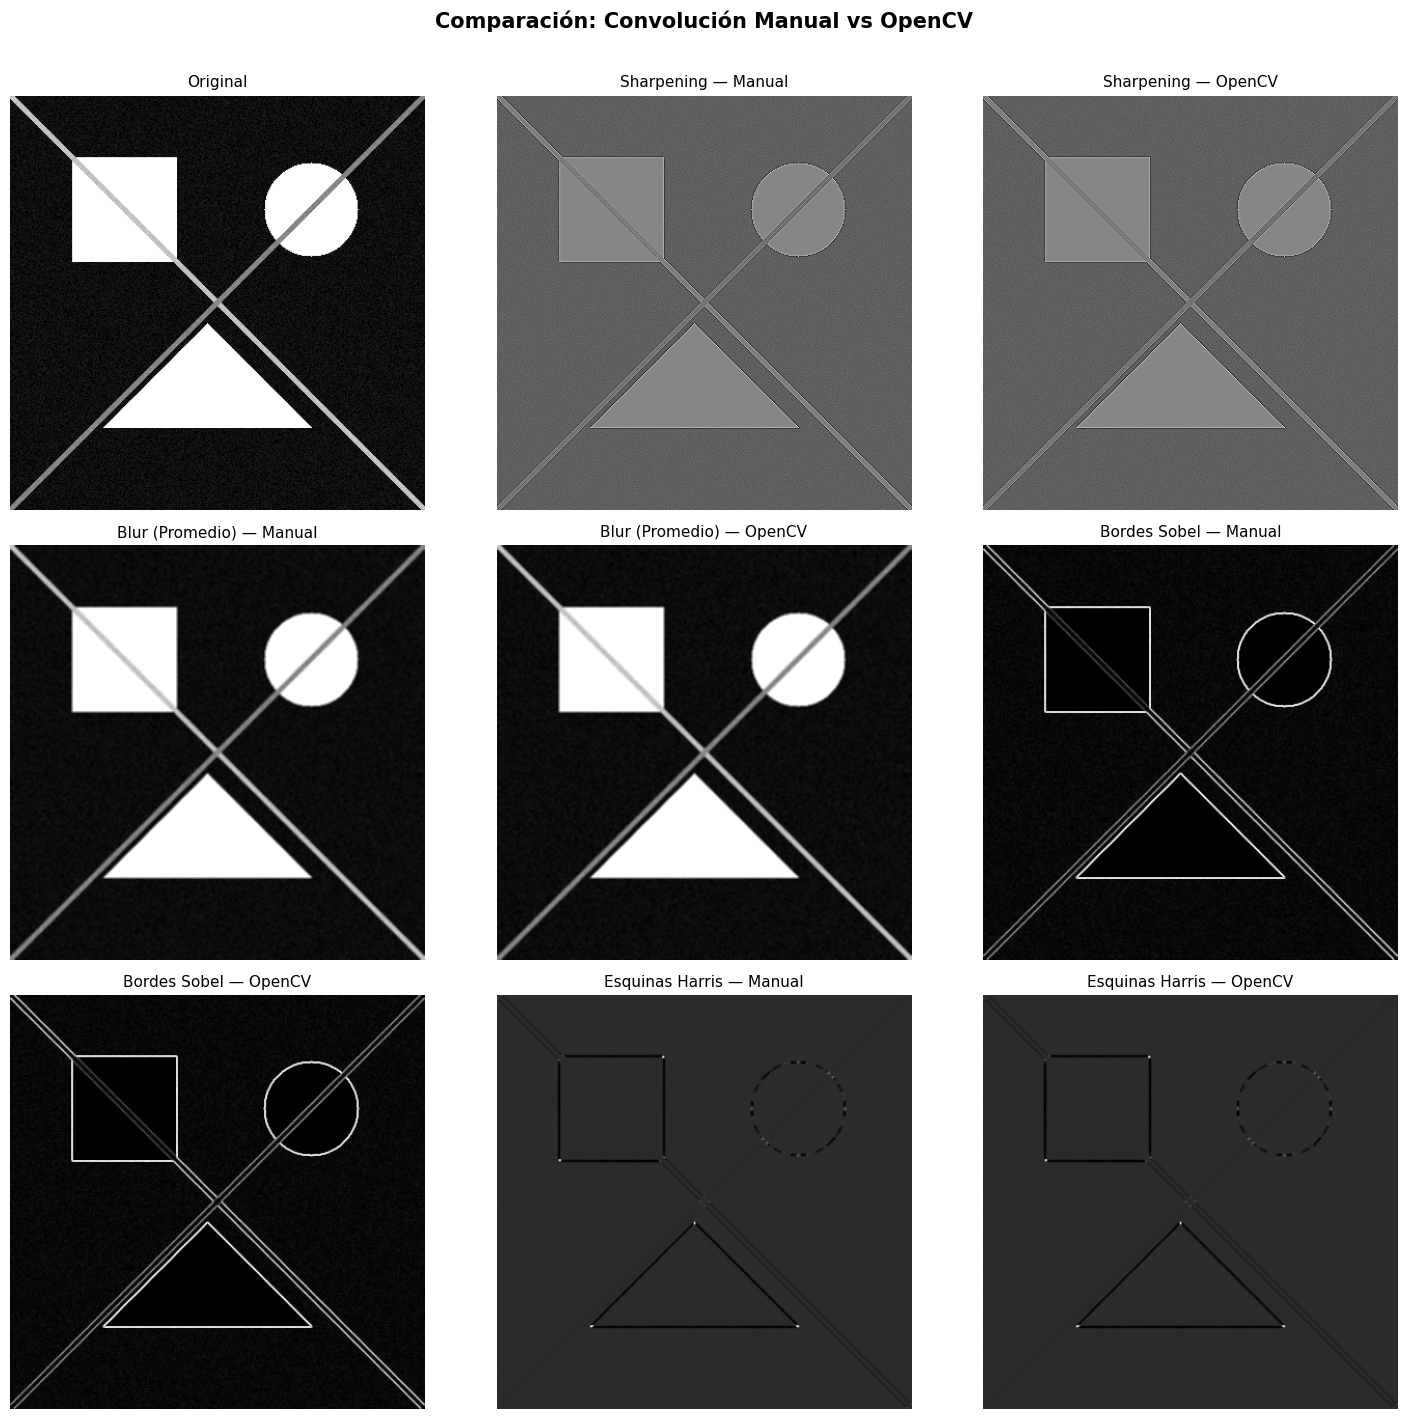

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
fig.suptitle("Comparación: Convolución Manual vs OpenCV", fontsize=15, fontweight='bold', y=1.01)

images = [
    (img,             "Original",                  None),
    (sharp_manual_u8, "Sharpening — Manual",        None),
    (sharp_cv_u8,     "Sharpening — OpenCV",        None),
    (blur_manual_u8,  "Blur (Promedio) — Manual",   None),
    (blur_cv_u8,      "Blur (Promedio) — OpenCV",   None),
    (edges_manual_u8, "Bordes Sobel — Manual",      None),
    (edges_cv_u8,     "Bordes Sobel — OpenCV",      None),
    (corner_manual_u8,"Esquinas Harris — Manual",   None),
    (corner_cv_u8,    "Esquinas Harris — OpenCV",   None),
]

for ax, (im, title, cm) in zip(axes.ravel(), images):
    ax.imshow(im, cmap=cm or "gray")
    ax.set_title(title, fontsize=11, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Celda 9: Análisis de diferencia entre manual y OpenCV

Se calcula el **error absoluto medio (MAE)** para verificar que ambas implementaciones producen resultados equivalentes.

In [9]:
def mae(a, b):
    """Error Absoluto Medio entre dos arrays."""
    return np.mean(np.abs(a.astype(np.float32) - b.astype(np.float32)))

print("=" * 50)
print("  Error Absoluto Medio (Manual vs OpenCV)")
print("=" * 50)
print(f"  Sharpening : {mae(sharp_manual_u8,  sharp_cv_u8):.4f}")
print(f"  Blur       : {mae(blur_manual_u8,   blur_cv_u8):.4f}")
print(f"  Bordes     : {mae(edges_manual_u8,  edges_cv_u8):.4f}")
print(f"  Esquinas   : {mae(corner_manual_u8, corner_cv_u8):.4f}")
print("=" * 50)
print("\nMAE cercano a 0 → implementaciones equivalentes.")

  Error Absoluto Medio (Manual vs OpenCV)
  Sharpening : 0.0000
  Blur       : 0.1480
  Bordes     : 0.0000
  Esquinas   : 0.0000

MAE cercano a 0 → implementaciones equivalentes.


## Celda 10: Comparación de tiempos de ejecución

Midiendo tiempos (sharpening como benchmark)...

  Tiempo implementación manual : 5.1877 s
  Tiempo OpenCV (filter2D)     : 0.001439 s
  Razón de velocidad           : 3604x más rápido con OpenCV

Razón: OpenCV está implementado en C++, compilado y optimizado con SIMD/AVX.
La versión manual en Python puro es educativa, no para producción.


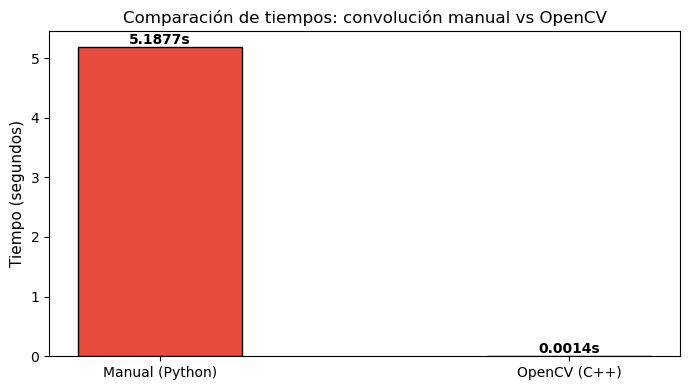

In [10]:
print("Midiendo tiempos (sharpening como benchmark)...\n")

# Tiempo manual
start = time.time()
_ = conv2d_manual(img, kernel_sharpen)
t_manual = time.time() - start

# Tiempo OpenCV
start = time.time()
_ = cv2.filter2D(img, cv2.CV_32F, kernel_sharpen, borderType=cv2.BORDER_REFLECT101)
t_opencv = time.time() - start

print(f"  Tiempo implementación manual : {t_manual:.4f} s")
print(f"  Tiempo OpenCV (filter2D)     : {t_opencv:.6f} s")
print(f"  Razón de velocidad           : {t_manual/t_opencv:.0f}x más rápido con OpenCV")
print()
print("Razón: OpenCV está implementado en C++, compilado y optimizado con SIMD/AVX.")
print("La versión manual en Python puro es educativa, no para producción.")

# Gráfica de barras de comparación
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Manual (Python)", "OpenCV (C++)"],
              [t_manual, t_opencv],
              color=["#e74c3c", "#2ecc71"], edgecolor="black", width=0.4)
ax.set_ylabel("Tiempo (segundos)", fontsize=11)
ax.set_title("Comparación de tiempos: convolución manual vs OpenCV", fontsize=12)
for bar, val in zip(bars, [t_manual, t_opencv]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

## Celda 11: Guardar resultados en `media/`

In [11]:
os.makedirs("media", exist_ok=True)

archivos = {
    "media/original.png":        img,
    "media/sharpen_manual.png":  sharp_manual_u8,
    "media/sharpen_cv.png":      sharp_cv_u8,
    "media/blur_manual.png":     blur_manual_u8,
    "media/blur_cv.png":         blur_cv_u8,
    "media/edges_manual.png":    edges_manual_u8,
    "media/edges_cv.png":        edges_cv_u8,
    "media/corners_manual.png":  corner_manual_u8,
    "media/corners_cv.png":      corner_cv_u8,
}

for path, im in archivos.items():
    cv2.imwrite(path, im)
    print(f"  Guardada: {path}")

print("\nTodas las imágenes guardadas en la carpeta media/")

  Guardada: media/original.png
  Guardada: media/sharpen_manual.png
  Guardada: media/sharpen_cv.png
  Guardada: media/blur_manual.png
  Guardada: media/blur_cv.png
  Guardada: media/edges_manual.png
  Guardada: media/edges_cv.png
  Guardada: media/corners_manual.png
  Guardada: media/corners_cv.png

Todas las imágenes guardadas en la carpeta media/


## Celda 12 (Bonus): Interfaz interactiva con `cv2.createTrackbar`

> **Solo funciona en entorno local con ventanas GUI**
> Descomenta la última línea para ejecutarlo en tu computador.

In [ ]:
def interactive_kernel_demo(image):
    """
    Interfaz interactiva con sliders para probar diferentes valores de kernel 3x3.
    Cada trackbar controla un elemento del kernel en el rango [-10, 10].
    Presiona ESC para salir.
    """
    def nothing(x):
        pass

    win = "Kernel interactivo (ESC para salir)"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 700, 550)

    # Crear un trackbar por cada elemento del kernel 3x3 (rango 0-20, centro=10 -> 0)
    for i in range(3):
        for j in range(3):
            default_val = 10  # Equivale a 0 en el kernel
            cv2.createTrackbar(f"k[{i}][{j}]", win, default_val, 20, nothing)

    # Presets predefinidos como textos en la ventana
    print("Presets de kernel para probar:")
    print("  Identidad (sin cambio):  k[1][1]=10, resto=10")
    print("  Sharpening:  k[0][1]=9, k[1][0]=9, k[1][1]=14, k[1][2]=9, k[2][1]=9")
    print("  Blur:        todos en 10 (valor 1/9) no funciona directo — usa la imagen original")

    while True:
        kernel = np.zeros((3, 3), dtype=np.float32)
        for i in range(3):
            for j in range(3):
                val = cv2.getTrackbarPos(f"k[{i}][{j}]", win)
                kernel[i, j] = val - 10  # Convertir de [0,20] a [-10,10]

        # Aplicar filtro
        filtered = cv2.filter2D(image, cv2.CV_32F, kernel,
                                borderType=cv2.BORDER_REFLECT101)
        filtered_u8 = normalize_uint8(filtered)

        cv2.imshow(win, filtered_u8)

        key = cv2.waitKey(1) & 0xFF
        if key == 27:  # ESC
            break

    cv2.destroyAllWindows()
    print("Ventana interactiva cerrada.")

print("Función interactive_kernel_demo definida.")
print("Descomenta la siguiente línea para ejecutar (solo entorno local con GUI):")
print()
print("  # interactive_kernel_demo(img)")

# ↓ Descomenta solo si ejecutas localmente (no en Colab)
# interactive_kernel_demo(img)

Función interactive_kernel_demo definida.
Descomenta la siguiente línea para ejecutar (solo entorno local con GUI):

  # interactive_kernel_demo(img)
Presets de kernel para probar:
  Identidad (sin cambio):  k[1][1]=10, resto=10
  Sharpening:  k[0][1]=9, k[1][0]=9, k[1][1]=14, k[1][2]=9, k[2][1]=9
  Blur:        todos en 10 (valor 1/9) no funciona directo — usa la imagen original


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2570: error: (-27:Null pointer) NULL window: 'Kernel interactivo (ESC para salir)' in function 'cvGetTrackbarPos'


---
## Resumen del taller

| Actividad | Estado |
|-----------|--------|
| Carga de imagen en escala de grises | ✅ |
| Convolución 2D manual desde cero (NumPy) | ✅ |
| Kernel 1: Sharpening (enfoque) | ✅ |
| Kernel 2: Blur / Suavizado | ✅ |
| Kernel 3: Bordes + Esquinas (Sobel + $I_x I_y$) | ✅ |
| Comparación visual Manual vs OpenCV | ✅ |
| Análisis de error (MAE) | ✅ |
| Comparación de tiempos de ejecución | ✅ |
| Bonus: Interfaz interactiva con trackbars | ✅ |